In [1]:
!nvidia-smi


Fri Oct 10 09:36:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
#@title Config de base (GPU, chemins, sorties)

import os, random, time, math, glob
from PIL import Image
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA dispo:", torch.cuda.is_available())

# === Chemins (on garde TEL QUEL l'arbo créée par tes ZIP) ===
A_TRAIN = "/content/datasets/Gan/processed64/img_celeb/64img_celeb/train"
A_TEST  = "/content/datasets/Gan/processed64/img_celeb/64img_celeb/test"
B_TRAIN = "/content/datasets/Gan/processed64/paint_portrait/64paint_portrait/train"
B_TEST  = "/content/datasets/Gan/processed64/paint_portrait/64paint_portrait/test"

# === Dossier de sortie (samples, checkpoints, logs) ===
OUT_DIR = "/content/outputs"
DIR_SAMPLES = f"{OUT_DIR}/samples"
DIR_CKPT    = f"{OUT_DIR}/ckpt"
DIR_LOGS    = f"{OUT_DIR}/logs"
os.makedirs(DIR_SAMPLES, exist_ok=True)
os.makedirs(DIR_CKPT, exist_ok=True)
os.makedirs(DIR_LOGS, exist_ok=True)

# Fixe les seeds (reproductible-ish)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Hyperparamètres principaux
BATCH_SIZE = 16  # baisse si OOM (8, 4, ...)
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
LR = 2e-4
BETA1, BETA2 = 0.5, 0.999
EPOCHS = 100            # augmente si besoin
LAMBDA_CYCLE = 10.0
LAMBDA_ID    = 5.0
SAVE_GRID_N  = 6       # nb d'images par ligne dans les grilles


CUDA dispo: True


In [10]:
#@title Dataset & DataLoaders (64×64 déjà prêt)

import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

class FlatImageFolder(Dataset):
    def __init__(self, root, transform=None, exts=(".jpg",".jpeg",".png",".webp")):
        self.paths = sorted([p for p in glob.glob(os.path.join(root, "**"), recursive=True)
                             if os.path.isfile(p) and p.lower().endswith(exts)])
        if len(self.paths) == 0:
            raise RuntimeError(f"Aucune image trouvée: {root}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img) if self.transform else img

# Transforms simples (déjà 64x64)
transform_train = T.Compose([
    T.RandomHorizontalFlip(0.5),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

ds_A_train = FlatImageFolder(A_TRAIN, transform_train)
ds_B_train = FlatImageFolder(B_TRAIN, transform_train)
ds_A_val   = FlatImageFolder(A_TEST,  transform_test)
ds_B_val   = FlatImageFolder(B_TEST,  transform_test)

pin = torch.cuda.is_available()
loader_A = DataLoader(ds_A_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True, persistent_workers=pin)
loader_B = DataLoader(ds_B_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True, persistent_workers=pin)
val_A = DataLoader(ds_A_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
val_B = DataLoader(ds_B_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print(f"A: train {len(ds_A_train)} | val {len(ds_A_val)}")
print(f"B: train {len(ds_B_train)} | val {len(ds_B_val)}")


A: train 7365 | val 818
B: train 3233 | val 359


In [11]:
#@title Modèles CycleGAN (ResNet-6 à 64×64, PatchGAN ~46×46 pour 64px)

import torch.nn as nn
import torchvision
from torchvision.utils import make_grid, save_image

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c, c, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(c),
            nn.ReLU(inplace=True),
            nn.Conv2d(c, c, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(c),
        )
    def forward(self, x): return x + self.net(x)

class ResnetGenerator(nn.Module):
    def __init__(self, in_c=3, out_c=3, n_blocks=6, ngf=64):
        super().__init__()
        layers = [nn.Conv2d(in_c, ngf, 7, 1, 3, bias=False), nn.InstanceNorm2d(ngf), nn.ReLU(True)]
        layers += [nn.Conv2d(ngf, ngf*2, 3, 2, 1, bias=False), nn.InstanceNorm2d(ngf*2), nn.ReLU(True)]
        layers += [nn.Conv2d(ngf*2, ngf*4, 3, 2, 1, bias=False), nn.InstanceNorm2d(ngf*4), nn.ReLU(True)]
        for _ in range(n_blocks): layers += [ResBlock(ngf*4)]
        layers += [nn.ConvTranspose2d(ngf*4, ngf*2, 3, 2, 1, output_padding=1, bias=False),
                   nn.InstanceNorm2d(ngf*2), nn.ReLU(True)]
        layers += [nn.ConvTranspose2d(ngf*2, ngf, 3, 2, 1, output_padding=1, bias=False),
                   nn.InstanceNorm2d(ngf), nn.ReLU(True)]
        layers += [nn.Conv2d(ngf, out_c, 7, 1, 3), nn.Tanh()]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class PatchDiscriminator(nn.Module):
    """Adapté 64×64: dernière conv 1×1 -> ~46×46 receptive field (vrai patch)."""
    def __init__(self, in_c=3, ndf=64):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True),                     # 64 -> 32
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.InstanceNorm2d(ndf*2), nn.LeakyReLU(0.2, True),  # 32 -> 16
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.InstanceNorm2d(ndf*4), nn.LeakyReLU(0.2, True),# 16 -> 8
            nn.Conv2d(ndf*4, ndf*8, 4, 1, 1, bias=False), nn.InstanceNorm2d(ndf*8), nn.LeakyReLU(0.2, True),# 8 -> 8
            nn.Conv2d(ndf*8, 1, 1, 1, 0)  # 1x1 head -> carte 7x7 sur entrée 64x64
        ]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

G_AB = ResnetGenerator().to(device)
G_BA = ResnetGenerator().to(device)
D_A  = PatchDiscriminator().to(device)
D_B  = PatchDiscriminator().to(device)

G_AB.apply(init_weights); G_BA.apply(init_weights); D_A.apply(init_weights); D_B.apply(init_weights)

sum_params = lambda m: sum(p.numel() for p in m.parameters())/1e6
print(f"G_AB: {sum_params(G_AB):.2f}M | G_BA: {sum_params(G_BA):.2f}M | D_A: {sum_params(D_A):.2f}M | D_B: {sum_params(D_B):.2f}M")


G_AB: 7.83M | G_BA: 7.83M | D_A: 2.76M | D_B: 2.76M


In [12]:
#@title Pertes/optims + utilitaires (AMP, samples, checkpoints à chaque époque, CSV)

import torch.nn as nn
import torch.optim as optim
import csv

mse = nn.MSELoss()
l1  = nn.L1Loss()

opt_G   = optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=LR, betas=(BETA1, BETA2))
opt_D_A = optim.Adam(D_A.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_D_B = optim.Adam(D_B.parameters(), lr=LR, betas=(BETA1, BETA2))

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def denorm(x): return (x * 0.5 + 0.5).clamp(0,1)

@torch.no_grad()
def save_sample_grid(a_batch, b_batch, epoch, n=SAVE_GRID_N):
    G_AB.eval(); G_BA.eval()
    a = a_batch[:n].to(device); b = b_batch[:n].to(device)
    fake_b = G_AB(a); rec_a = G_BA(fake_b)
    fake_a = G_BA(b); rec_b = G_AB(fake_a)
    grid = torch.cat([denorm(a), denorm(fake_b), denorm(rec_a),
                      denorm(b), denorm(fake_a), denorm(rec_b)], dim=0)
    grid = torchvision.utils.make_grid(grid, nrow=n)
    path = f"{DIR_SAMPLES}/epoch_{epoch:04d}.png"
    torchvision.utils.save_image(grid, path)
    print(f"✔️ Samples: {path}")

def save_ckpt(epoch, extra=None):
    state = {
        "epoch": epoch,
        "G_AB": G_AB.state_dict(),
        "G_BA": G_BA.state_dict(),
        "D_A":  D_A.state_dict(),
        "D_B":  D_B.state_dict(),
        "opt_G":   opt_G.state_dict(),
        "opt_D_A": opt_D_A.state_dict(),
        "opt_D_B": opt_D_B.state_dict(),
        "config": {
            "lr": LR, "betas": (BETA1, BETA2),
            "lambda_cycle": LAMBDA_CYCLE, "lambda_id": LAMBDA_ID,
            "batch_size": BATCH_SIZE
        }
    }
    if extra: state["extra"] = extra
    path = f"{DIR_CKPT}/ckpt_epoch_{epoch:04d}.pt"
    torch.save(state, path)
    print(f"💾 Checkpoint: {path}")

def log_losses_csv(epoch, logs_dict, csv_path=f"{DIR_LOGS}/losses.csv"):
    is_new = not os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["epoch"] + list(logs_dict.keys()))
        if is_new: writer.writeheader()
        row = {"epoch": epoch}; row.update(logs_dict)
        writer.writerow(row)


/tmp/ipython-input-1199896990.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [13]:
#@title Entraînement (époques)

from itertools import cycle
import time

def one_epoch(epoch_idx):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()
    iter_A = cycle(loader_A)
    iter_B = cycle(loader_B)
    steps = max(len(loader_A), len(loader_B))  # couvre le plus long

    d_a_sum = d_b_sum = g_adv_sum = cyc_sum = id_sum = 0.0

    for step in range(steps):
        A = next(iter_A).to(device, non_blocking=True)
        B = next(iter_B).to(device, non_blocking=True)

        # --- Discriminateurs ---
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            fake_A = G_BA(B).detach()
            d_a_real = D_A(A); d_a_fake = D_A(fake_A)
            loss_D_A = 0.5*(mse(d_a_real, torch.ones_like(d_a_real)) +
                             mse(d_a_fake, torch.zeros_like(d_a_fake)))

            fake_B = G_AB(A).detach()
            d_b_real = D_B(B); d_b_fake = D_B(fake_B)
            loss_D_B = 0.5*(mse(d_b_real, torch.ones_like(d_b_real)) +
                             mse(d_b_fake, torch.zeros_like(d_b_fake)))

            loss_D = loss_D_A + loss_D_B

        opt_D_A.zero_grad(set_to_none=True)
        opt_D_B.zero_grad(set_to_none=True)
        scaler.scale(loss_D).backward()
        scaler.step(opt_D_A); scaler.step(opt_D_B)

        # --- Générateurs ---
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            fake_B = G_AB(A); out_fake_B = D_B(fake_B)
            loss_G_AB_adv = mse(out_fake_B, torch.ones_like(out_fake_B))

            fake_A = G_BA(B); out_fake_A = D_A(fake_A)
            loss_G_BA_adv = mse(out_fake_A, torch.ones_like(out_fake_A))

            rec_A = G_BA(fake_B); rec_B = G_AB(fake_A)
            loss_cycle = torch.mean(torch.abs(rec_A - A)) + torch.mean(torch.abs(rec_B - B))

            idt_A = G_BA(A); idt_B = G_AB(B)
            loss_id = torch.mean(torch.abs(idt_A - A)) + torch.mean(torch.abs(idt_B - B))

            loss_G = (loss_G_AB_adv + loss_G_BA_adv) + LAMBDA_CYCLE*loss_cycle + LAMBDA_ID*loss_id

        opt_G.zero_grad(set_to_none=True)
        scaler.scale(loss_G).backward()
        scaler.step(opt_G)
        scaler.update()

        d_a_sum += loss_D_A.item()
        d_b_sum += loss_D_B.item()
        g_adv_sum += (loss_G_AB_adv.item() + loss_G_BA_adv.item())
        cyc_sum   += loss_cycle.item()
        id_sum    += loss_id.item()

        if (step+1) % 100 == 0 or (step+1)==steps:
            print(f"Ep {epoch_idx} | {step+1}/{steps} | "
                  f"D_A:{loss_D_A.item():.3f} D_B:{loss_D_B.item():.3f} | "
                  f"Gadv:{(loss_G_AB_adv.item()+loss_G_BA_adv.item()):.3f} | "
                  f"Cycle:{loss_cycle.item():.3f} Id:{loss_id.item():.3f}")

    logs = {
        "D_A": d_a_sum/steps,
        "D_B": d_b_sum/steps,
        "G_adv": g_adv_sum/steps,
        "Cycle": cyc_sum/steps,
        "Id": id_sum/steps
    }
    return logs

all_logs = []
t0 = time.time()
for epoch in range(1, EPOCHS+1):
    logs = one_epoch(epoch)
    all_logs.append({"epoch": epoch, **logs})

    # samples sur la val
    with torch.no_grad():
        a_batch = next(iter(val_A))
        b_batch = next(iter(val_B))
        save_sample_grid(a_batch, b_batch, epoch)

    # checkpoint + CSV
    save_ckpt(epoch, extra={"logs": logs})
    log_losses_csv(epoch, logs)

print(f"✅ Fini en {(time.time()-t0)/60:.1f} min")


/tmp/ipython-input-2951824278.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipython-input-2951824278.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Ep 1 | 100/460 | D_A:0.259 D_B:0.259 | Gadv:0.775 | Cycle:0.468 Id:0.414
Ep 1 | 200/460 | D_A:0.192 D_B:0.273 | Gadv:0.873 | Cycle:0.522 Id:0.399
Ep 1 | 300/460 | D_A:0.176 D_B:0.186 | Gadv:0.928 | Cycle:0.305 Id:0.290
Ep 1 | 400/460 | D_A:0.216 D_B:0.177 | Gadv:0.940 | Cycle:0.337 Id:0.314


/tmp/ipython-input-2951824278.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipython-input-2951824278.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Ep 1 | 460/460 | D_A:0.173 D_B:0.205 | Gadv:0.912 | Cycle:0.297 Id:0.276
✔️ Samples: /content/outputs/samples/epoch_0001.png
💾 Checkpoint: /content/outputs/ckpt/ckpt_epoch_0001.pt
Ep 2 | 100/460 | D_A:0.253 D_B:0.217 | Gadv:0.915 | Cycle:0.340 Id:0.301
Ep 2 | 200/460 | D_A:0.210 D_B:0.213 | Gadv:0.917 | Cycle:0.351 Id:0.287
Ep 2 | 300/460 | D_A:0.193 D_B:0.180 | Gadv:0.984 | Cycle:0.282 Id:0.265
Ep 2 | 400/460 | D_A:0.153 D_B:0.195 | Gadv:0.994 | Cycle:0.328 Id:0.296
Ep 2 | 460/460 | D_A:0.190 D_B:0.211 | Gadv:0.871 | Cycle:0.272 Id:0.259
✔️ Samples: /content/outputs/samples/epoch_0002.png
💾 Checkpoint: /content/outputs/ckpt/ckpt_epoch_0002.pt
Ep 3 | 100/460 | D_A:0.178 D_B:0.183 | Gadv:0.959 | Cycle:0.305 Id:0.275
Ep 3 | 200/460 | D_A:0.139 D_B:0.194 | Gadv:0.928 | Cycle:0.309 Id:0.274
Ep 3 | 300/460 | D_A:0.194 D_B:0.210 | Gadv:0.895 | Cycle:0.274 Id:0.257
Ep 3 | 400/460 | D_A:0.226 D_B:0.219 | Gadv:0.831 | Cycle:0.311 Id:0.280
Ep 3 | 460/460 | D_A:0.166 D_B:0.184 | Gadv:1.013 | Cycl

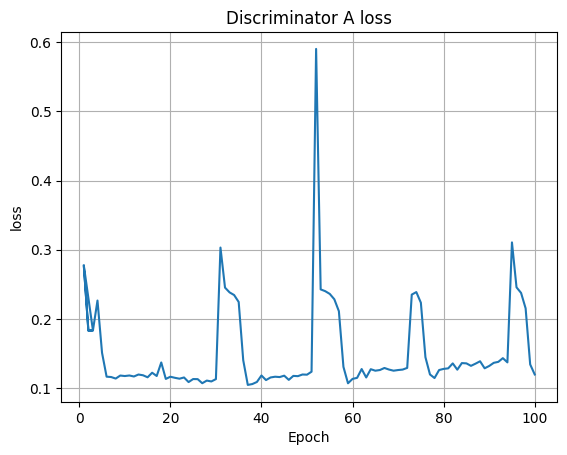

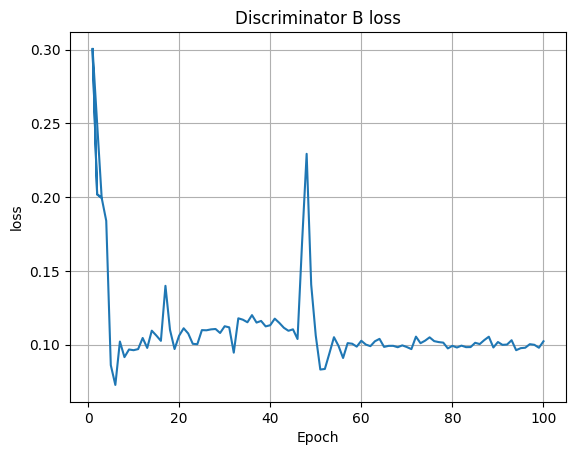

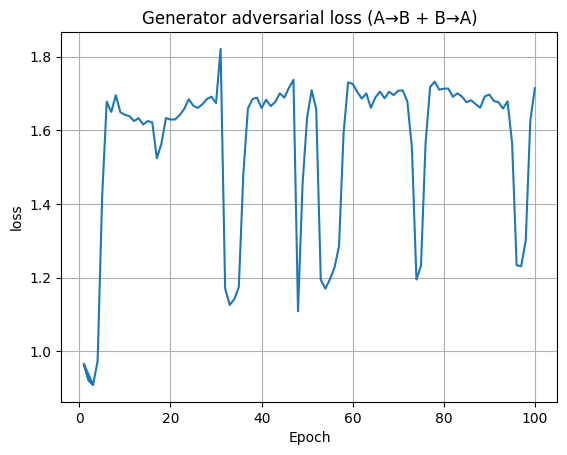

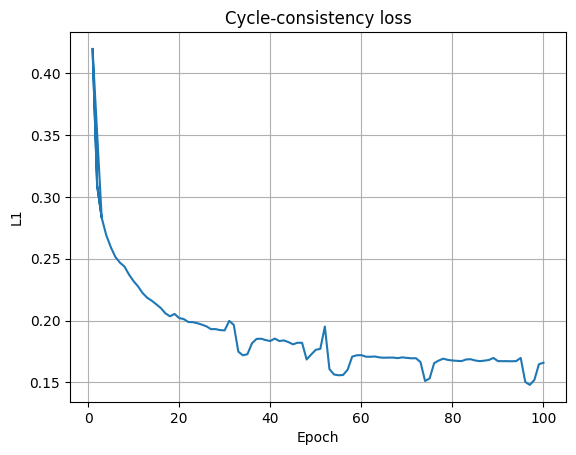

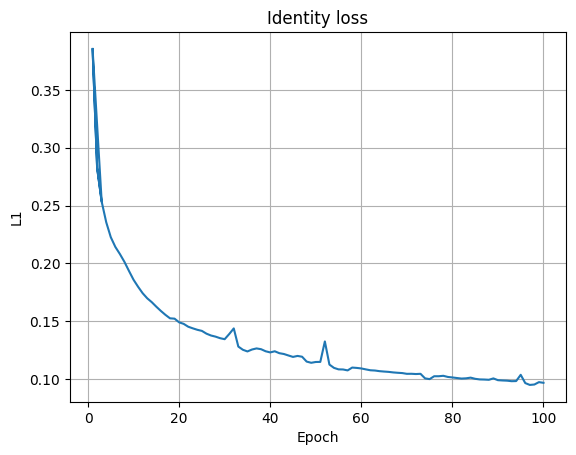

In [14]:
#@title Courbes de pertes (moyennes par époque)

import matplotlib.pyplot as plt
import csv

csv_path = f"{DIR_LOGS}/losses.csv"
epochs, d_a, d_b, g_adv, cyc, ide = [], [], [], [], [], []
with open(csv_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        epochs.append(int(row["epoch"]))
        d_a.append(float(row["D_A"]))
        d_b.append(float(row["D_B"]))
        g_adv.append(float(row["G_adv"]))
        cyc.append(float(row["Cycle"]))
        ide.append(float(row["Id"]))

def plot_line(x, y, title, ylabel):
    plt.figure()
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

plot_line(epochs, d_a,   "Discriminator A loss", "loss")
plot_line(epochs, d_b,   "Discriminator B loss", "loss")
plot_line(epochs, g_adv, "Generator adversarial loss (A→B + B→A)", "loss")
plot_line(epochs, cyc,   "Cycle-consistency loss", "L1")
plot_line(epochs, ide,   "Identity loss", "L1")


In [15]:
#@title Reprise depuis le dernier checkpoint (optionnel)

def latest_ckpt(path=DIR_CKPT):
    cks = sorted(glob.glob(os.path.join(path, "ckpt_epoch_*.pt")))
    return cks[-1] if cks else None

ck = latest_ckpt()
if ck is None:
    print("Aucun checkpoint trouvé.")
else:
    state = torch.load(ck, map_location=device)
    G_AB.load_state_dict(state["G_AB"])
    G_BA.load_state_dict(state["G_BA"])
    D_A.load_state_dict(state["D_A"])
    D_B.load_state_dict(state["D_B"])
    opt_G.load_state_dict(state["opt_G"])
    opt_D_A.load_state_dict(state["opt_D_A"])
    opt_D_B.load_state_dict(state["opt_D_B"])
    start_epoch = state.get("epoch", 0)
    print(f"Checkpoint chargé: {ck} (epoch {start_epoch})")


Checkpoint chargé: /content/outputs/ckpt/ckpt_epoch_0100.pt (epoch 100)


In [16]:
#@title Inférence rapide de contrôle

import torch
from torchvision.utils import make_grid, save_image

@torch.no_grad()
def preview_after_training():
    G_AB.eval(); G_BA.eval()
    a_batch = next(iter(val_A))[:SAVE_GRID_N].to(device)
    b_batch = next(iter(val_B))[:SAVE_GRID_N].to(device)
    fake_b = G_AB(a_batch); rec_a = G_BA(fake_b)
    fake_a = G_BA(b_batch); rec_b = G_AB(fake_a)
    grid = torch.cat([denorm(a_batch), denorm(fake_b), denorm(rec_a),
                      denorm(b_batch), denorm(fake_a), denorm(rec_b)], dim=0)
    grid = make_grid(grid, nrow=SAVE_GRID_N)
    path = f"{DIR_SAMPLES}/preview.png"
    save_image(grid, path)
    print(f"Prévisualisation: {path}")

preview_after_training()


Prévisualisation: /content/outputs/samples/preview.png


A (celeb):    /content/datasets/Gan/processed64/img_celeb/64img_celeb/test/001245.jpg
B (painting): /content/datasets/Gan/processed64/paint_portrait/64paint_portrait/test/01castig.jpg


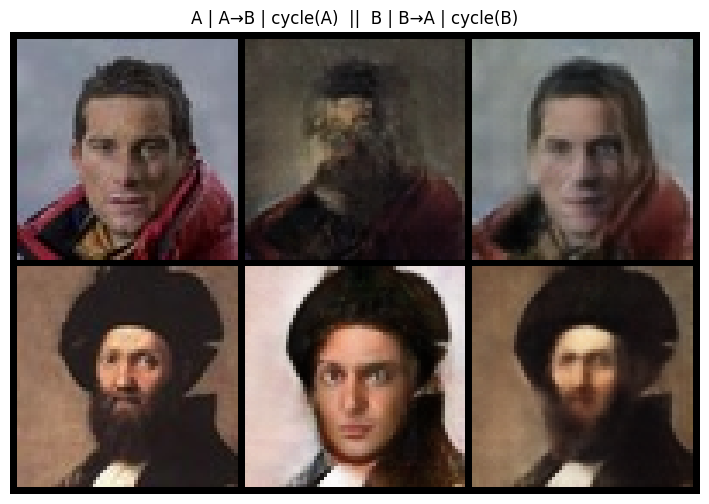

💾 Image sauvegardée: /content/outputs/samples/random_inference_20251010_123517.png


In [20]:
#@title Inférence aléatoire: une image de A (celeb) et une de B (painting)

import random, glob
from PIL import Image
import torchvision.transforms as T
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from datetime import datetime

# Choix des dossiers: prends dans le test par défaut (change en train si tu veux)
A_DIR = A_TEST   # celeb
B_DIR = B_TEST   # painting

# Transform test (identique à ta Cellule 2)
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

# 1) Prendre un fichier au hasard dans chaque domaine
def rand_image_path(root, exts=(".jpg",".jpeg",".png",".webp")):
    paths = [p for p in glob.glob(os.path.join(root, "**"), recursive=True)
             if os.path.isfile(p) and p.lower().endswith(exts)]
    if not paths:
        raise RuntimeError(f"Aucune image trouvée sous: {root}")
    return random.choice(paths)

a_path = rand_image_path(A_DIR)
b_path = rand_image_path(B_DIR)
print("A (celeb):   ", a_path)
print("B (painting):", b_path)

# 2) Charger & préprocess
def load_tensor(p):
    img = Image.open(p).convert("RGB")
    return transform_test(img).unsqueeze(0).to(device)  # [1,3,64,64]

a = load_tensor(a_path)
b = load_tensor(b_path)

# 3) Inférence: A->B, cycle(A); B->A, cycle(B)
G_AB.eval(); G_BA.eval()
with torch.no_grad():
    fake_b = G_AB(a)
    rec_a  = G_BA(fake_b)
    fake_a = G_BA(b)
    rec_b  = G_AB(fake_a)

# 4) Construire une grille: A | A→B | cycle(A) | B | B→A | cycle(B)
def denorm(x): return (x*0.5 + 0.5).clamp(0,1)

grid = torch.cat([denorm(a), denorm(fake_b), denorm(rec_a),
                  denorm(b), denorm(fake_a), denorm(rec_b)], dim=0)
grid = make_grid(grid, nrow=3)  # 2 lignes de 3 images

# 5) Afficher
plt.figure(figsize=(9,6))
plt.imshow(grid.permute(1,2,0).cpu().numpy())
plt.axis("off")
plt.title("A | A→B | cycle(A)  ||  B | B→A | cycle(B)")
plt.show()

# 6) Sauvegarder
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"{DIR_SAMPLES}/random_inference_{ts}.png"
save_image(grid, out_path)
print("💾 Image sauvegardée:", out_path)
